In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from lacbox.io import ReadHAWC2
from lacbox.test import test_data_path

In [139]:
# indices = [index for index, value in enumerate(df.chaninfo[1]) if value == "kW"] # replace df with the dataframe from simulation

In [27]:
import matplotlib.pyplot as plt
import numpy as np

def plot_wind_turbine_data(c1,c2,c3, title:str):
    # Create a figure and two sets of 2x2 subplots
    fig, axs = plt.subplots(2, 2, figsize=(18, 10))

    # Adjust the layout to prevent overlapping
    # fig.tight_layout(pad=7.0)
    fig.subplots_adjust(hspace=0.2, wspace=0.1)
    fig.suptitle(f"{title}", fontsize=16, y=0.93)
    # C1-3 plots (first set)
    axs[0, 0].plot(c1["time"], c1["wind_speed"])
    axs[0, 0].plot(c2["time"], c2["wind_speed"])
    axs[0, 0].plot(c3["time"], c3["wind_speed"])
    axs[0, 0].set_title('Wind Speed')
    # axs[0, 0].set_xlabel('Time')
    axs[0, 0].set_ylabel('Wind Speed [m/s]')
    axs[0, 0].grid()

    axs[0, 1].plot(c1["time"], c1["pitch"], label ='$\omega_{\Omega}$=0.05 Hz & $\zeta_{\Omega}=0.7 $')
    axs[0, 1].plot(c2["time"], c2["pitch"], label ='$\omega_{\Omega}$=0.01 Hz & $\zeta_{\Omega}=0.7 $')
    axs[0, 1].plot(c3["time"], c3["pitch"], label ='$\omega_{\Omega}$=0.10 Hz & $\zeta_{\Omega}=0.7 $')
    axs[0, 1].set_title('Pitch Angle')
    # axs[0, 1].set_xlabel('Time')
    axs[0, 1].legend(loc='upper left')
    axs[0, 1].set_ylabel('Pitch [Deg]')
    axs[0, 1].grid()


    axs[1, 0].plot(c1["time"], c1["rotational_speed"])
    axs[1, 0].plot(c2["time"], c2["rotational_speed"])
    axs[1, 0].plot(c3["time"], c3["rotational_speed"])
    axs[1, 0].set_title('Rotational Speed')
    axs[1, 0].set_xlabel('Time [s]')
    axs[1, 0].set_ylabel('$\Omega$ [Rad/sec]')
    axs[1, 0].grid()


    axs[1, 1].plot(c1["time"], c1["elec_power"])
    axs[1, 1].plot(c2["time"], c2["elec_power"])
    axs[1, 1].plot(c3["time"], c3["elec_power"])
    axs[1, 1].set_title('Electrical Power')
    axs[1, 1].set_xlabel('Time [s]')
    
    axs[1, 1].set_ylabel('Power [w]')
    axs[1,1].grid()


    # # C4-6 plots (second set)
    # axs[2, 0].plot(c4["time"], c4["wind_speed"])
    # axs[2, 0].plot(c5["time"], c5["wind_speed"])
    # axs[2, 0].plot(c6["time"], c6["wind_speed"])

    # # axs[2, 0].set_xlabel('Time')
    # axs[2, 0].set_title('Wind Speed')
    # axs[2, 0].set_ylabel('Wind Speed [m/s]')
    # axs[2,0].grid()


    # axs[2, 1].plot(c4["time"], c4["pitch"], label ='$\omega_{\Omega}$=0.05 Hz & r"$\zeta_{\Omega}=0.7 $')
    # axs[2, 1].plot(c5["time"], c5["pitch"], label ='$\omega_{\Omega}$=0.01 Hz & r"$\zeta_{\Omega}=0.7 $')
    # axs[2, 1].plot(c6["time"], c6["pitch"], label ='$\omega_{\Omega}$=0.10 Hz & r"$\zeta_{\Omega}=0.7 $')
    # axs[2, 1].legend()
    # axs[2, 1].set_title('Pitch Angle')
    # # axs[2, 1].set_xlabel('Time')
    # axs[2, 1].set_ylabel('Pitch [Deg]')
    # axs[2,1].grid()


    # axs[3, 0].plot(c4["time"], c4["rotational_speed"])
    # axs[3, 0].plot(c5["time"], c5["rotational_speed"])
    # axs[3, 0].plot(c6["time"], c6["rotational_speed"])
    # axs[3, 0].set_title('Rotational Speed')
    # axs[3, 0].set_xlabel('Time [s]')
    # axs[3, 0].set_ylabel('$\Omega$ [Rad/sec]')
    # axs[3,0].grid()


    # axs[3, 1].plot(c4["time"], c4["elec_power"])
    # axs[3, 1].plot(c5["time"], c5["elec_power"])
    # axs[3, 1].plot(c6["time"], c6["elec_power"])
    # axs[3, 1].set_title('Electrical Power')
    # axs[3, 1].set_xlabel('Time [s]')
    # axs[3, 1].set_ylabel('Power [w]')
    # axs[3,1].grid() 
    plt.show()




In [3]:
df1 = ReadHAWC2("part_3_results/group7_3B_design_A3_part3_C1.hdf5")
df2 = ReadHAWC2("part_3_results/group7_3B_design_A3_part3_C2.hdf5")
df3 = ReadHAWC2("part_3_results/group7_3B_design_A3_part3_C3.hdf5")
df4 = ReadHAWC2("part_3_results/group7_3B_design_A3_part3_C4.hdf5")
df5 = ReadHAWC2("part_3_results/group7_3B_design_A3_part3_C5.hdf5")
df6 = ReadHAWC2("part_3_results/group7_3B_design_A3_part3_C6.hdf5")

In [4]:
def extract_values_for_part_3(df):

    return {
        'pitch': df.data[:,3],
        'rotational_speed': df.data[:,9],
        'elec_power': df.data[:,104],
        'wind_speed': df.data[:, 16],
        'time': df.data[:,0]
    }

In [5]:
c1 = extract_values_for_part_3(df1)
c2 = extract_values_for_part_3(df2)
c3 = extract_values_for_part_3(df3)
c4 = extract_values_for_part_3(df4)
c5 = extract_values_for_part_3(df5)
c6 = extract_values_for_part_3(df6)

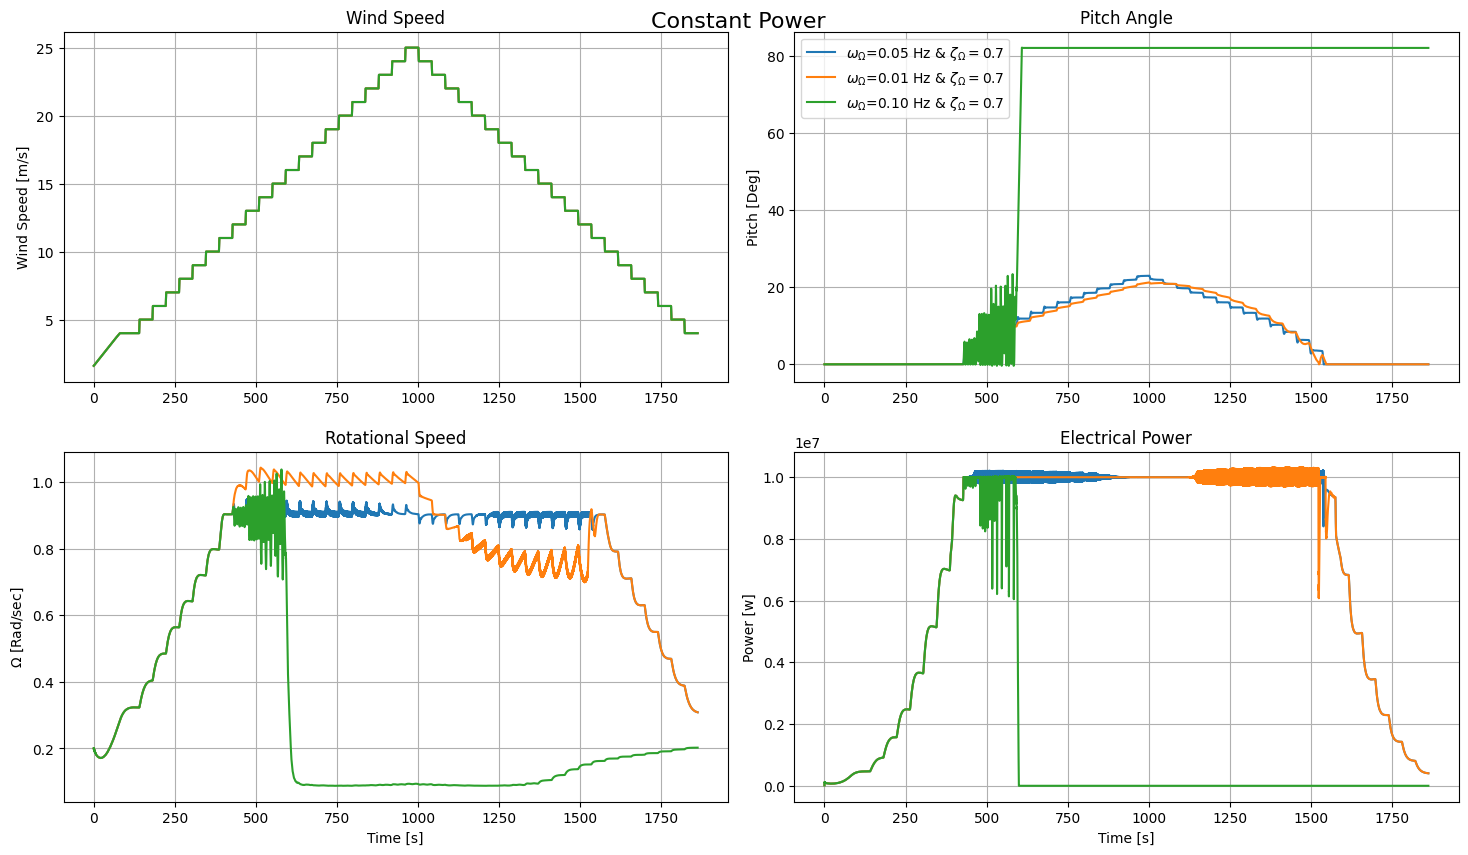

In [28]:
plot_wind_turbine_data(c1, c2, c3, "Constant Power")

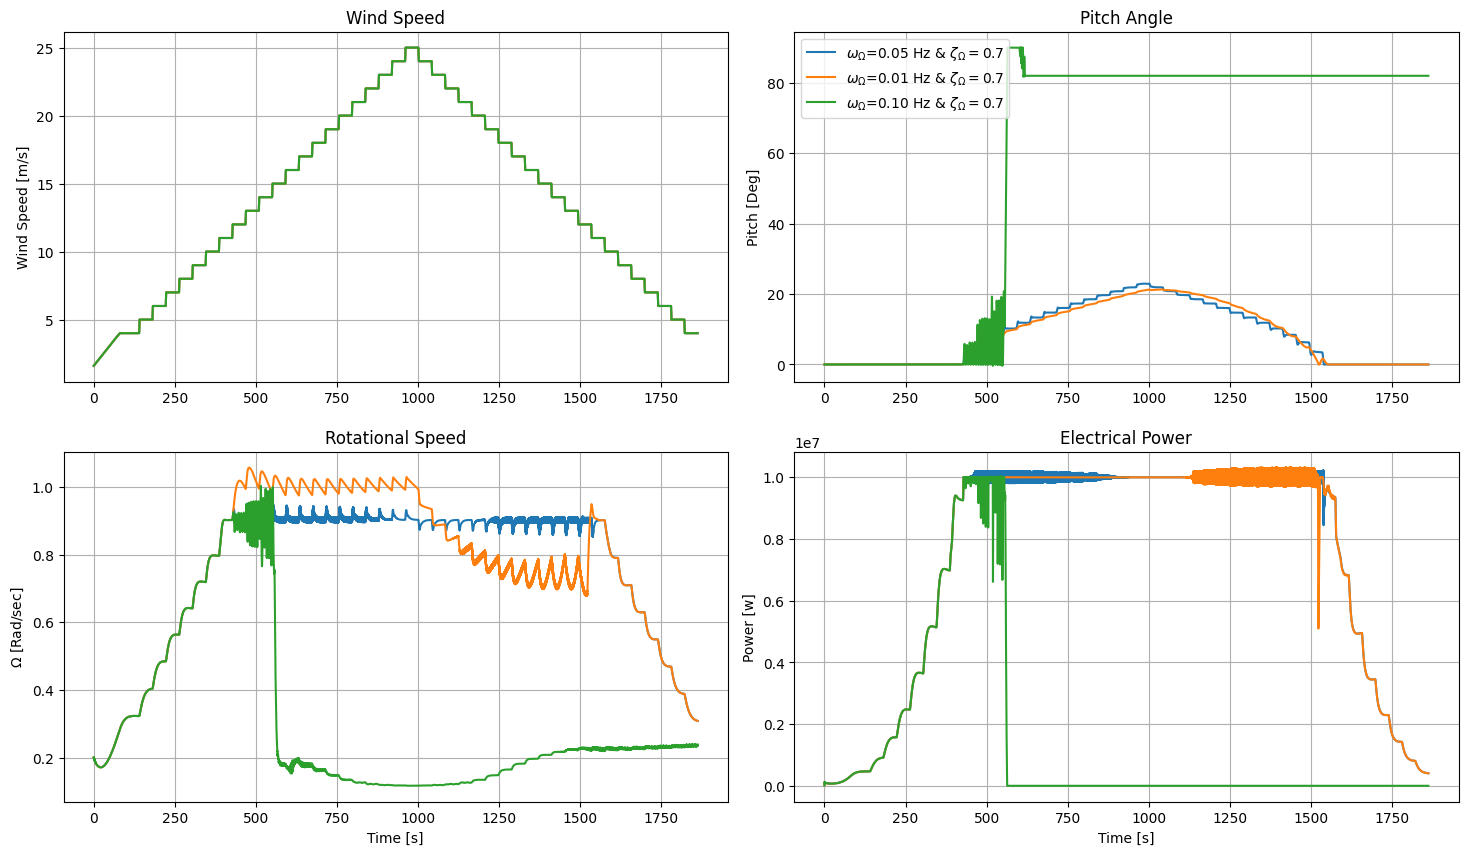

In [19]:
plot_wind_turbine_data(c4, c5, c6)
